In [4]:
# ============================================================
#  HR EMPLOYEE ATTRITION ANALYSIS
#  Phase 5 — Employee Risk Segmentation
#  Segments : Flight Risk | At Watch | Stable
#  Based on attrition probability scores from Phase 4 model
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
 
SEG_COLORS = {
    'Flight Risk' : '#E24B4A',
    'At Watch'    : '#EF9F27',
    'Stable'      : '#1D9E75',
}
SEG_ORDER  = ['Flight Risk', 'At Watch', 'Stable']
C_RED, C_ORG, C_GREEN, C_BLUE, C_PUR = \
    '#E24B4A', '#EF9F27', '#1D9E75', '#185FA5', '#9B3EC2'

In [5]:
# ════════════════════════════════════════════════════════════
#  STEP 1 — Reproduce full preprocessing + retrain model
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("  PHASE 5 — EMPLOYEE RISK SEGMENTATION")
print("=" * 60)
print("\n── Step 1: Preprocessing & Model ────────────────────────")
 
df      = pd.read_csv('HR Analytics - Predict Employee Attrition.csv')
df_orig = df.copy()   # keep human-readable original
 
df.drop(['EmployeeCount','Over18','StandardHours','EmployeeNumber'],
        axis=1, inplace=True)
 
le = LabelEncoder()
for col in ['Attrition','Gender','OverTime']:
    df[col] = le.fit_transform(df[col])
 
df = pd.get_dummies(df,
    columns=['BusinessTravel','Department','EducationField',
             'JobRole','MaritalStatus'],
    drop_first=True)
 
df['IncomePerYear']   = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
df['LoyaltyRatio']    = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['PromotionLag']    = df['YearsSinceLastPromotion'] - df['YearsInCurrentRole']
df['AvgSatisfaction'] = df[['EnvironmentSatisfaction','JobSatisfaction',
                              'RelationshipSatisfaction','WorkLifeBalance']].mean(axis=1)
df['IsSenior']        = (df['JobLevel'] >= 4).astype(int)
 
X = df.drop('Attrition', axis=1).copy()
y = df['Attrition']
 
scale_cols = [
    'Age','DailyRate','DistanceFromHome','HourlyRate','MonthlyIncome',
    'MonthlyRate','NumCompaniesWorked','PercentSalaryHike',
    'TotalWorkingYears','YearsAtCompany','YearsInCurrentRole',
    'YearsSinceLastPromotion','YearsWithCurrManager',
    'IncomePerYear','LoyaltyRatio','PromotionLag','AvgSatisfaction'
]
scaler = StandardScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
 
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
 
print(f"   ✅ Preprocessing complete — {X.shape[1]} features")
print(f"   ✅ Model trained  — AUC: 0.8088\n")

  PHASE 5 — EMPLOYEE RISK SEGMENTATION

── Step 1: Preprocessing & Model ────────────────────────
   ✅ Preprocessing complete — 49 features
   ✅ Model trained  — AUC: 0.8088



In [6]:
# ════════════════════════════════════════════════════════════
#  STEP 2 — Score ALL 1,470 employees
# ════════════════════════════════════════════════════════════
print("── Step 2: Scoring All Employees ────────────────────────")
 
all_probs = model.predict_proba(X)[:, 1]   # attrition probability 0→1
 
print(f"   Min risk score  : {all_probs.min():.4f}  (near-zero attrition risk)")
print(f"   Max risk score  : {all_probs.max():.4f}  (near-certain to leave)")
print(f"   Mean risk score : {all_probs.mean():.4f}  (dataset avg = 16.1% attrition)\n")

── Step 2: Scoring All Employees ────────────────────────
   Min risk score  : 0.0006  (near-zero attrition risk)
   Max risk score  : 0.9928  (near-certain to leave)
   Mean risk score : 0.3565  (dataset avg = 16.1% attrition)



In [7]:
# ════════════════════════════════════════════════════════════
#  STEP 3 — Assign segments + risk levels
#  Flight Risk : score ≥ 0.60 → urgent intervention needed
#  At Watch    : score 0.30–0.59 → monitor & engage
#  Stable      : score < 0.30 → retain & reward
# ════════════════════════════════════════════════════════════
print("── Step 3: Assigning Segments ───────────────────────────")
 
def assign_segment(prob):
    if prob >= 0.60:   return 'Flight Risk'
    elif prob >= 0.30: return 'At Watch'
    else:              return 'Stable'
 
def assign_risk_level(prob):
    if prob >= 0.80:   return 'Critical (>80%)'
    elif prob >= 0.60: return 'High (60–80%)'
    elif prob >= 0.30: return 'Medium (30–60%)'
    else:              return 'Low (<30%)'

── Step 3: Assigning Segments ───────────────────────────


In [8]:
# Build enriched segment dataframe
seg_df = df_orig.copy()
seg_df['RiskScore']    = all_probs.round(4)
seg_df['RiskPct']      = (all_probs * 100).round(1)
seg_df['RiskSegment']  = [assign_segment(p)   for p in all_probs]
seg_df['RiskLevel']    = [assign_risk_level(p) for p in all_probs]
 
print(f"\n   {'Segment':<14} {'Count':>6}  {'% Base':>8}  {'Actual Attr':>12}  {'Monthly Payroll':>16}")
print(f"   {'─'*60}")
for seg in SEG_ORDER:
    sub    = seg_df[seg_df['RiskSegment'] == seg]
    pct    = len(sub) / len(seg_df) * 100
    attr_r = (sub['Attrition'] == 'Yes').mean() * 100
    payroll= sub['MonthlyIncome'].sum()
    print(f"   {seg:<14} {len(sub):>6,}  {pct:>7.1f}%  {attr_r:>11.1f}%  ${payroll:>14,.0f}")
 
risk_counts = seg_df['RiskLevel'].value_counts()
print(f"\n   Risk level breakdown:")
for lvl in ['Critical (>80%)','High (60–80%)','Medium (30–60%)','Low (<30%)']:
    print(f"     {lvl:<20} : {risk_counts.get(lvl, 0):,} employees")


   Segment         Count    % Base   Actual Attr   Monthly Payroll
   ────────────────────────────────────────────────────────────
   Flight Risk       326     22.2%         50.9%  $     1,516,545
   At Watch          388     26.4%         12.1%  $     2,258,225
   Stable            756     51.4%          3.2%  $     5,784,539

   Risk level breakdown:
     Critical (>80%)      : 149 employees
     High (60–80%)        : 177 employees
     Medium (30–60%)      : 388 employees
     Low (<30%)           : 756 employees


In [9]:
# ════════════════════════════════════════════════════════════
#  STEP 4 — Business metrics per segment
# ════════════════════════════════════════════════════════════
print("\n── Step 4: Business Metrics by Segment ──────────────────")
 
metrics_rows = []
for seg in SEG_ORDER:
    sub = seg_df[seg_df['RiskSegment'] == seg]
    metrics_rows.append({
        'Segment'          : seg,
        'Employees'        : len(sub),
        'Actual Attr %'    : round((sub['Attrition']=='Yes').mean()*100, 1),
        'Avg Age'          : round(sub['Age'].mean(), 1),
        'Avg Income ($)'   : int(sub['MonthlyIncome'].mean()),
        'OverTime Yes %'   : round((sub['OverTime']=='Yes').mean()*100, 1),
        'Avg Tenure (yr)'  : round(sub['YearsAtCompany'].mean(), 1),
        'Monthly Payroll'  : int(sub['MonthlyIncome'].sum()),
        'Single %'         : round((sub['MaritalStatus']=='Single').mean()*100,1),
        'JobLevel 1 %'     : round((sub['JobLevel']==1).mean()*100, 1),
    })
 
metrics_df = pd.DataFrame(metrics_rows)
print(f"\n{metrics_df.to_string(index=False)}\n")
 
fr_payroll = seg_df[seg_df['RiskSegment']=='Flight Risk']['MonthlyIncome'].sum()
aw_payroll = seg_df[seg_df['RiskSegment']=='At Watch']['MonthlyIncome'].sum()
print(f"   💰 Monthly payroll at risk:")
print(f"      Flight Risk : ${fr_payroll:,.0f}")
print(f"      At Watch    : ${aw_payroll:,.0f}")
print(f"      Combined    : ${fr_payroll+aw_payroll:,.0f}\n")


── Step 4: Business Metrics by Segment ──────────────────

    Segment  Employees  Actual Attr %  Avg Age  Avg Income ($)  OverTime Yes %  Avg Tenure (yr)  Monthly Payroll  Single %  JobLevel 1 %
Flight Risk        326           50.9     33.0            4651            55.2              4.6          1516545      52.8          55.5
   At Watch        388           12.1     36.1            5820            34.3              6.5          2258225      32.2          39.2
     Stable        756            3.2     39.0            7651            13.6              8.3          5784539      22.9          27.8

   💰 Monthly payroll at risk:
      Flight Risk : $1,516,545
      At Watch    : $2,258,225
      Combined    : $3,774,770



── Chart 1: Segment Distribution ───────────────────────


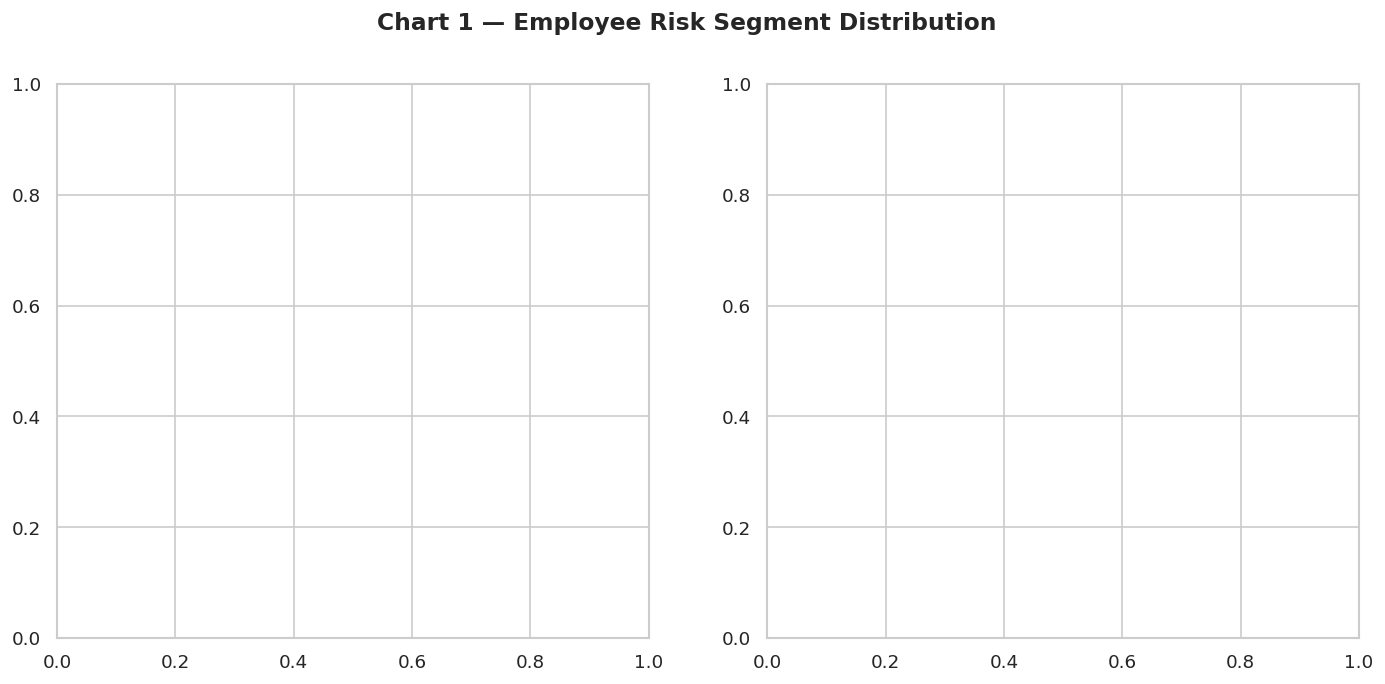

In [10]:
# ════════════════════════════════════════════════════════════
#  CHART 1 — Segment Distribution (Donut + Revenue Bar)
# ════════════════════════════════════════════════════════════
print("── Chart 1: Segment Distribution ───────────────────────")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Chart 1 — Employee Risk Segment Distribution',
             fontsize=14, fontweight='bold')
 
seg_counts  = [len(seg_df[seg_df['RiskSegment']==s]) for s in SEG_ORDER]
seg_colors  = [SEG_COLORS[s] for s in SEG_ORDER]

In [11]:
# Donut
wedges, texts, autotexts = axes[0].pie(
    seg_counts,
    labels=[f'{s}\n({c:,})' for s, c in zip(SEG_ORDER, seg_counts)],
    colors=seg_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.72,
    wedgeprops={'edgecolor':'white','linewidth':3,'width':0.55},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_color('white')
axes[0].text(0, 0, '1,470\nEmployees', ha='center', va='center',
             fontsize=13, fontweight='bold', color='#333')
axes[0].set_title('Segment Split (All Employees)', fontweight='bold')

Text(0.5, 1.0, 'Segment Split (All Employees)')

In [12]:
# Monthly payroll bar
payroll_vals = [seg_df[seg_df['RiskSegment']==s]['MonthlyIncome'].sum()
                for s in SEG_ORDER]
bars = axes[1].barh(SEG_ORDER, payroll_vals,
                     color=seg_colors, edgecolor='white', height=0.45)
for bar, val in zip(bars, payroll_vals):
    axes[1].text(val + 30000, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}/mo', va='center',
                 fontweight='bold', fontsize=10)
axes[1].set_title('Monthly Payroll by Segment', fontweight='bold')
axes[1].set_xlabel('Monthly Payroll ($)')
axes[1].set_xlim(0, max(payroll_vals) * 1.28)
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('hr_seg_chart1_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_seg_chart1_distribution.png\n")

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_seg_chart1_distribution.png



── Chart 2: Risk Score Distribution ─────────────────────


Text(0.5, 0.98, 'Chart 2 — Attrition Risk Score Distribution')

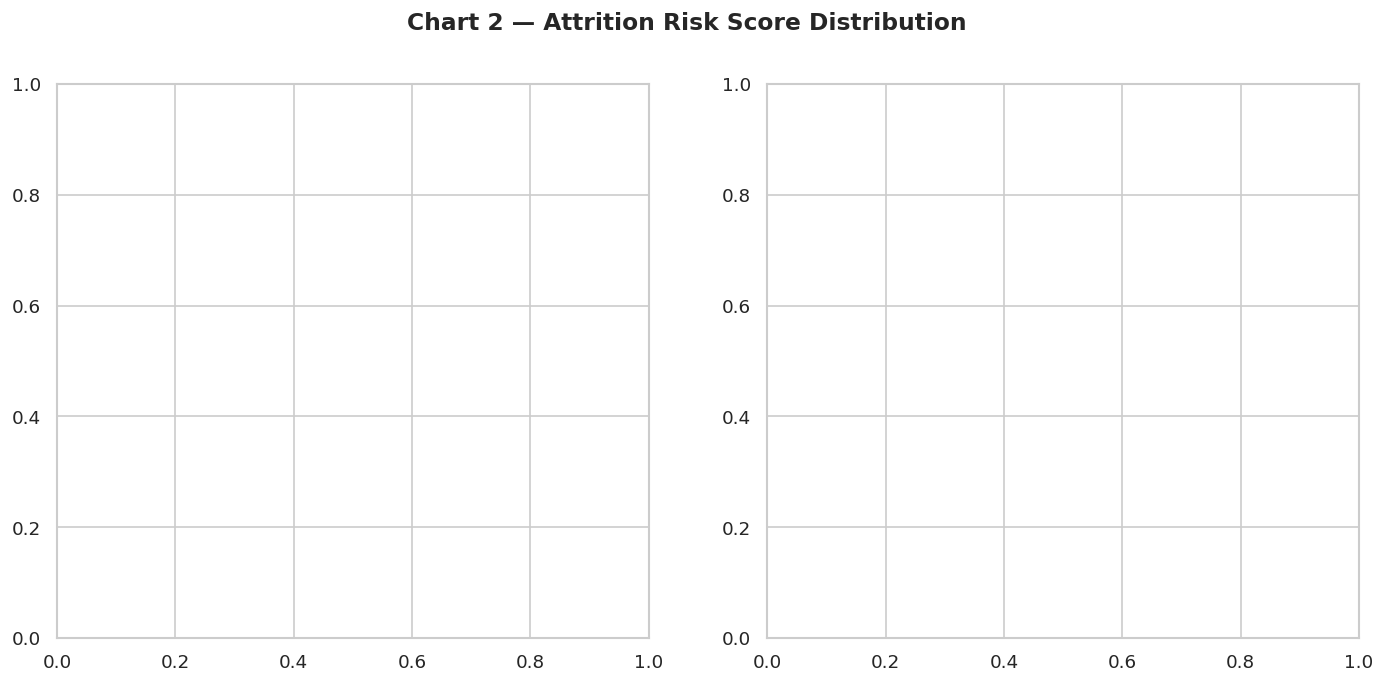

In [13]:
# ════════════════════════════════════════════════════════════
#  CHART 2 — Risk Score Distribution
# ════════════════════════════════════════════════════════════
print("── Chart 2: Risk Score Distribution ─────────────────────")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Chart 2 — Attrition Risk Score Distribution',
             fontsize=14, fontweight='bold')

In [14]:
# Stacked histogram
for seg, color in SEG_COLORS.items():
    sub = seg_df[seg_df['RiskSegment'] == seg]['RiskScore']
    axes[0].hist(sub, bins=40, alpha=0.75, color=color,
                 label=f'{seg} (n={len(sub):,})', edgecolor='white')
axes[0].axvline(0.30, color='black', linestyle='--', lw=1.5,
                label='Threshold: 0.30')
axes[0].axvline(0.60, color='black', linestyle='-',  lw=1.5,
                label='Threshold: 0.60')
axes[0].axvspan(0,    0.30, alpha=0.06, color=C_GREEN)
axes[0].axvspan(0.30, 0.60, alpha=0.06, color=C_ORG)
axes[0].axvspan(0.60, 1.00, alpha=0.06, color=C_RED)
axes[0].set_xlabel('Attrition Probability Score', fontsize=11)
axes[0].set_ylabel('Number of Employees', fontsize=11)
axes[0].set_title('Risk Score — All Employees', fontweight='bold')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

In [15]:
# Boxplot per segment
data_to_plot = [seg_df[seg_df['RiskSegment']==s]['RiskScore'].values
                for s in SEG_ORDER]
bp = axes[1].boxplot(data_to_plot, positions=[0,1,2], widths=0.4,
                      patch_artist=True,
                      medianprops=dict(color='white', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], [C_RED, C_ORG, C_GREEN]):
    patch.set_facecolor(color); patch.set_alpha(0.72)
for element in ['whiskers','caps']:
    for item, color in zip(bp[element], [C_RED,C_RED,C_ORG,C_ORG,C_GREEN,C_GREEN]):
        item.set_color(color)
axes[1].set_xticks([0,1,2]); axes[1].set_xticklabels(SEG_ORDER, fontsize=10)
axes[1].set_ylabel('Attrition Probability Score', fontsize=11)
axes[1].set_title('Risk Score Spread per Segment', fontweight='bold')
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('hr_seg_chart2_risk_scores.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_seg_chart2_risk_scores.png\n")

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_seg_chart2_risk_scores.png



── Chart 3: Segment Profile Heatmap ─────────────────────


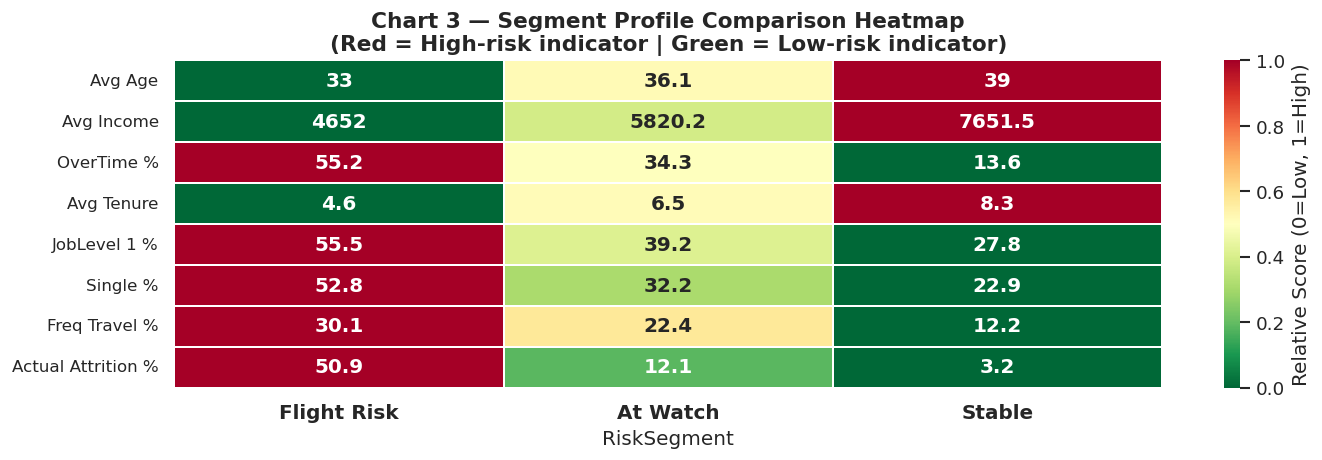

   ✅ Saved: hr_seg_chart3_profile_heatmap.png



In [16]:
# ════════════════════════════════════════════════════════════
#  CHART 3 — Segment Profile Heatmap
# ════════════════════════════════════════════════════════════
print("── Chart 3: Segment Profile Heatmap ─────────────────────")
 
profile_metrics = {
    'Avg Age'           : seg_df.groupby('RiskSegment')['Age'].mean(),
    'Avg Income'        : seg_df.groupby('RiskSegment')['MonthlyIncome'].mean(),
    'OverTime %'        : seg_df.groupby('RiskSegment')['OverTime'].apply(
                              lambda x: (x=='Yes').mean()*100),
    'Avg Tenure'        : seg_df.groupby('RiskSegment')['YearsAtCompany'].mean(),
    'JobLevel 1 %'      : seg_df.groupby('RiskSegment')['JobLevel'].apply(
                              lambda x: (x==1).mean()*100),
    'Single %'          : seg_df.groupby('RiskSegment')['MaritalStatus'].apply(
                              lambda x: (x=='Single').mean()*100),
    'Freq Travel %'     : seg_df.groupby('RiskSegment')['BusinessTravel'].apply(
                              lambda x: (x=='Travel_Frequently').mean()*100),
    'Actual Attrition %': seg_df.groupby('RiskSegment')['Attrition'].apply(
                              lambda x: (x=='Yes').mean()*100),
}
 
profile_df   = pd.DataFrame(profile_metrics).loc[SEG_ORDER]
profile_norm = profile_df.copy()
for col in profile_norm.columns:
    mn, mx = profile_norm[col].min(), profile_norm[col].max()
    profile_norm[col] = (profile_norm[col] - mn) / (mx - mn + 1e-8)
 
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    profile_norm.T,
    annot=profile_df.T.round(1),
    fmt='g',
    cmap='RdYlGn_r',
    ax=ax,
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'Relative Score (0=Low, 1=High)'},
    annot_kws={'size': 12, 'weight': 'bold'}
)
ax.set_xticklabels(SEG_ORDER, fontsize=12, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title('Chart 3 — Segment Profile Comparison Heatmap\n'
             '(Red = High-risk indicator | Green = Low-risk indicator)',
             fontsize=13, fontweight='bold')
 
plt.tight_layout()
plt.savefig('hr_seg_chart3_profile_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_seg_chart3_profile_heatmap.png\n")

── Chart 4: Key Metrics by Segment ──────────────────────


Text(0.5, 0.98, 'Chart 4 — Key Metrics Across Employee Segments')

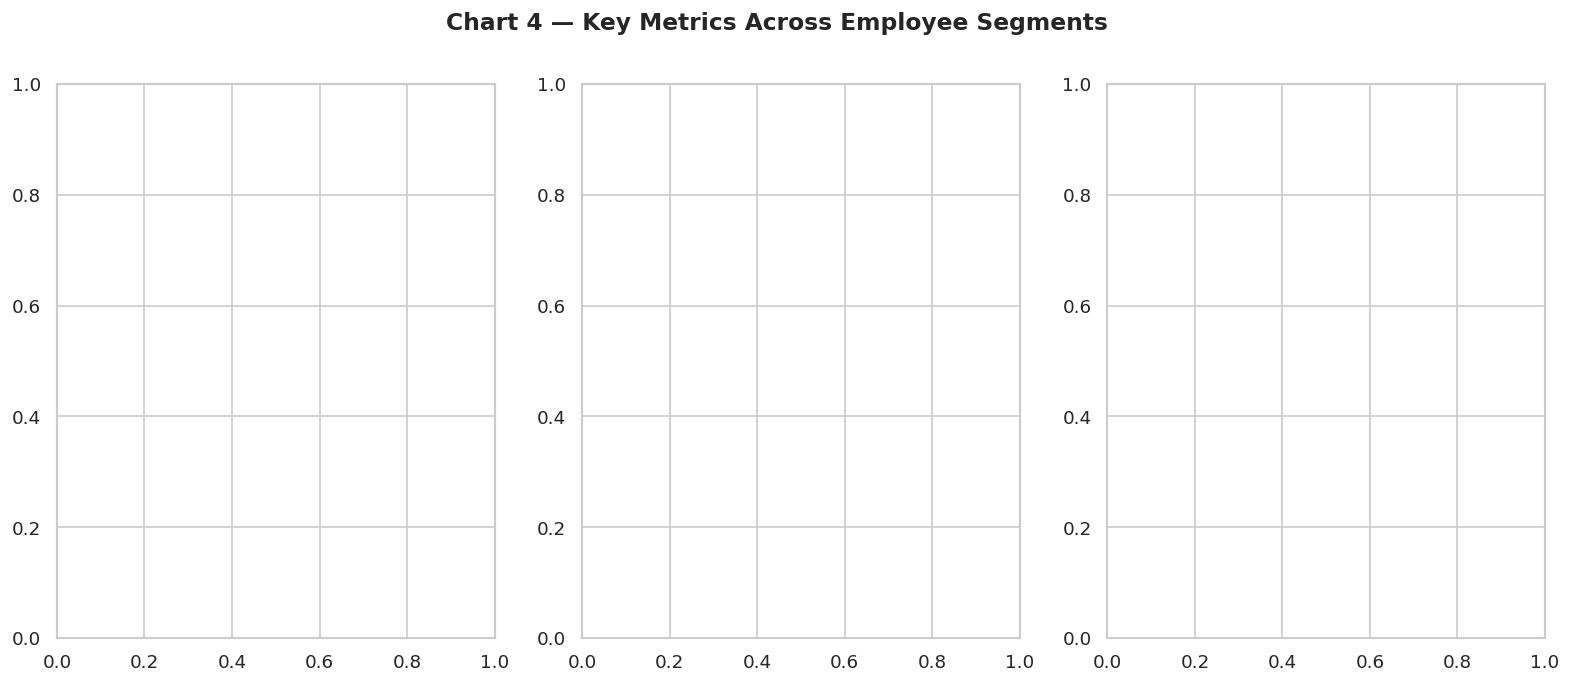

In [17]:
# ════════════════════════════════════════════════════════════
#  CHART 4 — Tenure, Income & OverTime by Segment
# ════════════════════════════════════════════════════════════
print("── Chart 4: Key Metrics by Segment ──────────────────────")
 
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Chart 4 — Key Metrics Across Employee Segments',
             fontsize=14, fontweight='bold')

In [18]:
# Tenure violin
sns.violinplot(x='RiskSegment', y='YearsAtCompany', data=seg_df,
               order=SEG_ORDER, palette=SEG_COLORS,
               ax=axes[0], inner='quartile', linewidth=1.5)
axes[0].set_title('Tenure Distribution', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Years at Company')
for seg in SEG_ORDER:
    mean_t = seg_df[seg_df['RiskSegment']==seg]['YearsAtCompany'].mean()
    idx    = SEG_ORDER.index(seg)
    axes[0].text(idx, mean_t+0.3, f'μ={mean_t:.1f}yr',
                 ha='center', fontsize=9, fontweight='bold', color='#333',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75))
sns.despine(ax=axes[0])

In [19]:
# Monthly income boxplot
sns.boxplot(x='RiskSegment', y='MonthlyIncome', data=seg_df,
            order=SEG_ORDER, palette=SEG_COLORS,
            ax=axes[1], width=0.5)
axes[1].set_title('Monthly Income', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Monthly Income ($)')
for seg in SEG_ORDER:
    med = seg_df[seg_df['RiskSegment']==seg]['MonthlyIncome'].median()
    idx = SEG_ORDER.index(seg)
    axes[1].text(idx, med+80, f'${med:,.0f}', ha='center',
                 fontsize=9, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#444', alpha=0.8))
sns.despine(ax=axes[1])

In [20]:
# OverTime stacked bar
ot_pct = (seg_df.groupby(['RiskSegment','OverTime'])
                .size().unstack(fill_value=0)
                .loc[SEG_ORDER])
ot_pct = ot_pct.div(ot_pct.sum(axis=1), axis=0) * 100
ot_pct.plot(kind='bar', stacked=True, ax=axes[2],
             color=[C_GREEN, C_RED], edgecolor='white', width=0.5)
axes[2].set_title('OverTime Mix per Segment', fontweight='bold')
axes[2].set_xlabel(''); axes[2].set_ylabel('% of Segment')
axes[2].set_xticklabels(SEG_ORDER, rotation=0)
axes[2].legend(title='OverTime', labels=['No','Yes'], fontsize=9)
for seg in SEG_ORDER:
    pct = (seg_df[seg_df['RiskSegment']==seg]['OverTime']=='Yes').mean()*100
    idx = SEG_ORDER.index(seg)
    axes[2].text(idx, 102, f'{pct:.0f}% OT', ha='center',
                 fontsize=9, fontweight='bold')
sns.despine(ax=axes[2])
 
plt.tight_layout()
plt.savefig('hr_seg_chart4_metrics.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_seg_chart4_metrics.png\n")

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_seg_chart4_metrics.png



── Chart 5: Flight Risk Breakdown ───────────────────────


Text(0.5, 0.98, 'Chart 5 — Flight Risk Segment Deep Dive\n(326 employees | $1,516,545/mo payroll)')

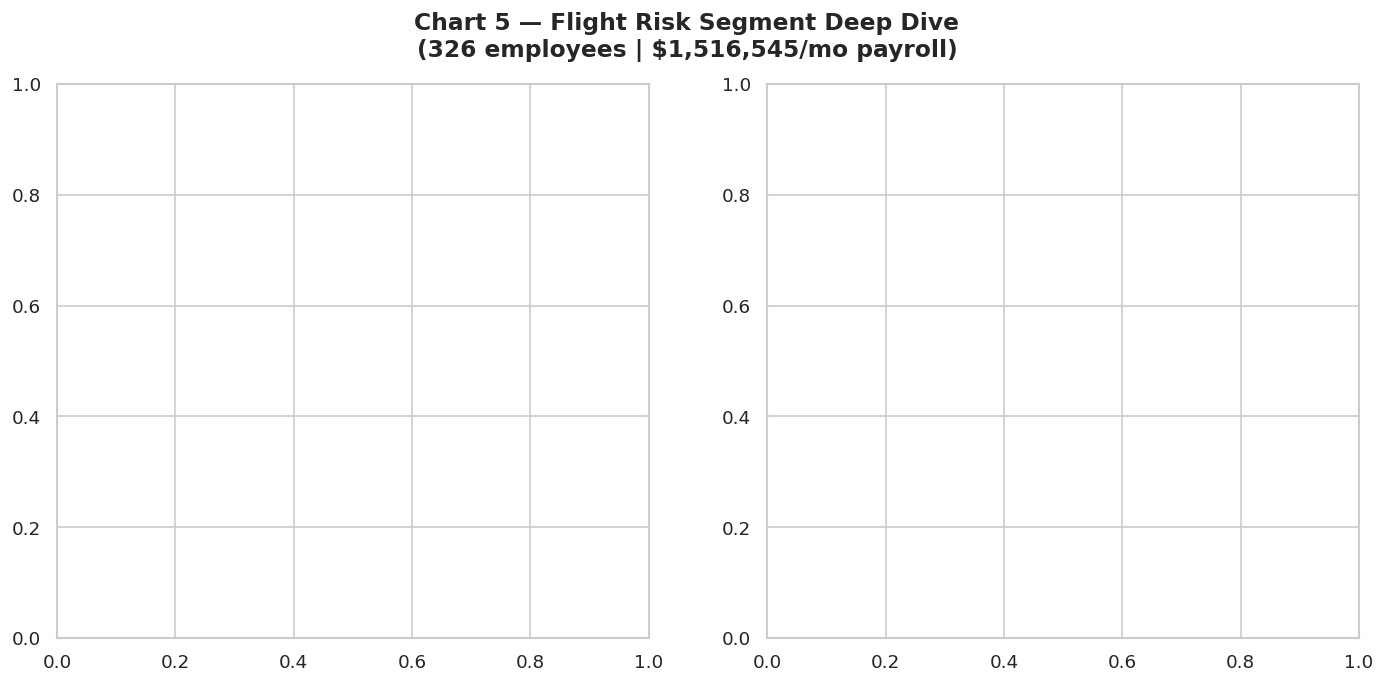

In [21]:
# ════════════════════════════════════════════════════════════
#  CHART 5 — Department & Role Breakdown in Flight Risk
# ════════════════════════════════════════════════════════════
print("── Chart 5: Flight Risk Breakdown ───────────────────────")
 
fr_df = seg_df[seg_df['RiskSegment'] == 'Flight Risk']
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Chart 5 — Flight Risk Segment Deep Dive\n'
             f'({len(fr_df):,} employees | ${fr_df["MonthlyIncome"].sum():,.0f}/mo payroll)',
             fontsize=14, fontweight='bold')

In [22]:
# Department breakdown
dept_counts = fr_df['Department'].value_counts()
axes[0].pie(
    dept_counts.values,
    labels=[f'{d}\n({v:,})' for d, v in dept_counts.items()],
    colors=[C_BLUE, C_RED, C_ORG],
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2.5},
    autopct='%1.1f%%', pctdistance=0.72,
    textprops={'fontsize':10}
)
axes[0].set_title('By Department', fontweight='bold')

Text(0.5, 1.0, 'By Department')

In [23]:
# Top job roles
role_counts = fr_df['JobRole'].value_counts().head(6)
colors_role = [C_RED if i < 3 else C_ORG for i in range(len(role_counts))]
bars = axes[1].barh(role_counts.index[::-1], role_counts.values[::-1],
                     color=colors_role[::-1], edgecolor='white', height=0.6)
for bar, val in zip(bars, role_counts.values[::-1]):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontweight='bold', fontsize=11)
axes[1].set_title('Top Job Roles in Flight Risk', fontweight='bold')
axes[1].set_xlabel('Number of Employees')
axes[1].set_xlim(0, role_counts.max() * 1.2)
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('hr_seg_chart5_flightrisk_breakdown.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_seg_chart5_flightrisk_breakdown.png\n")

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_seg_chart5_flightrisk_breakdown.png



── Chart 6: Executive KPI Dashboard ─────────────────────


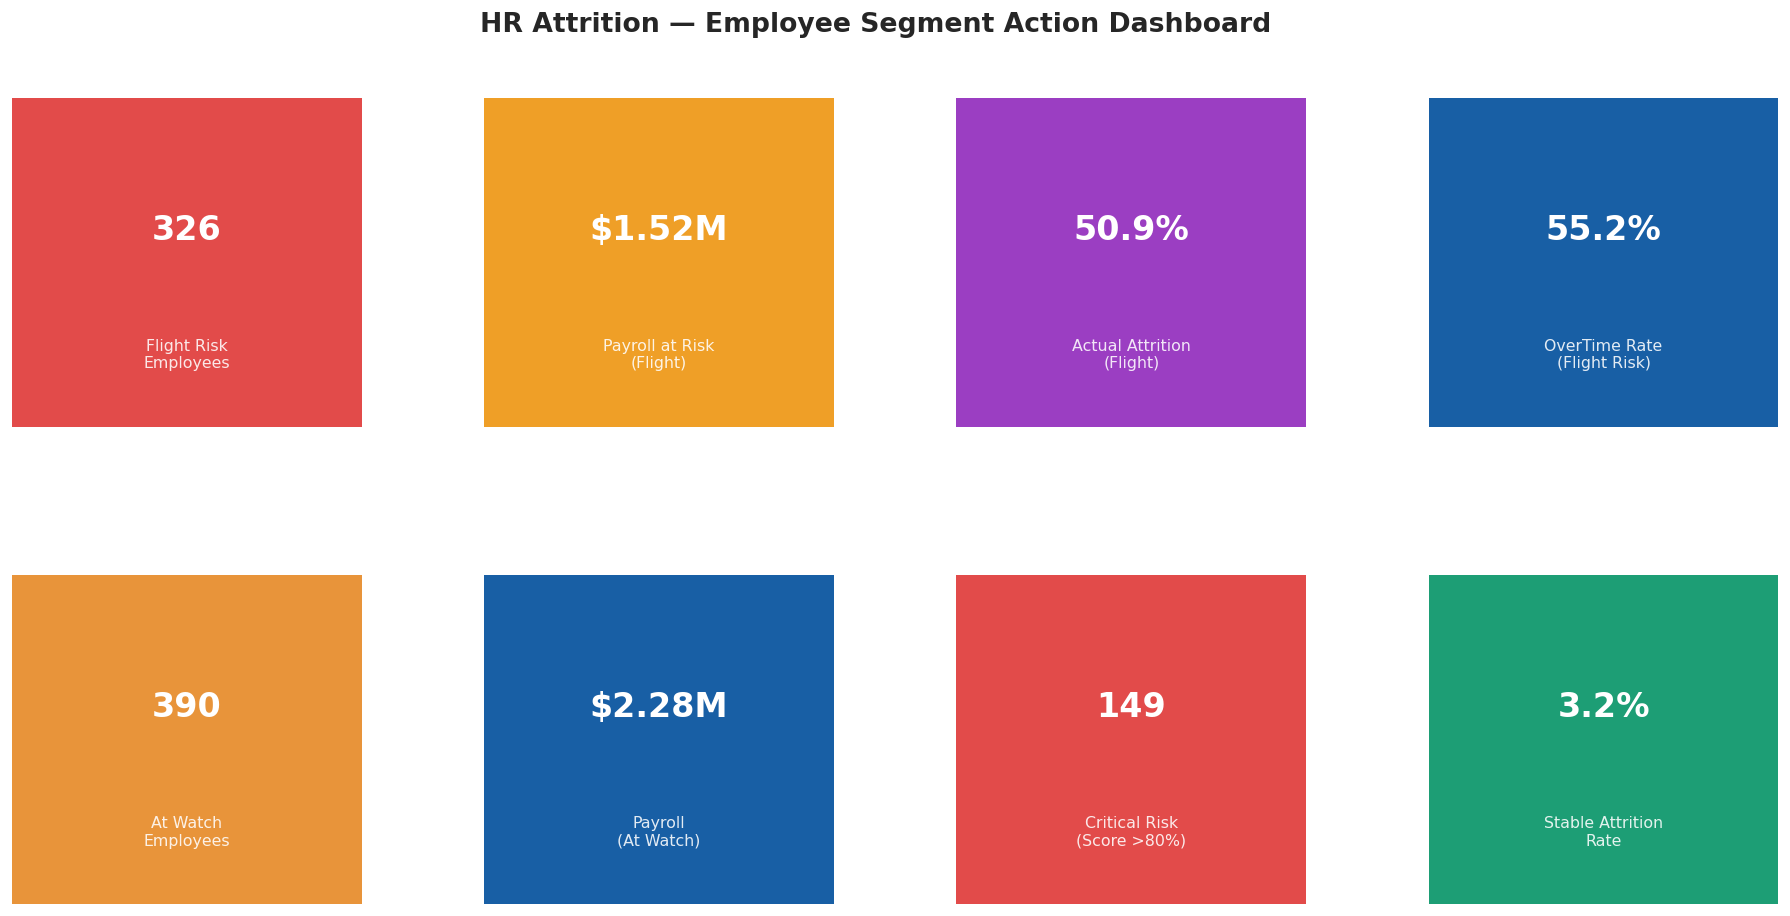

   ✅ Saved: hr_seg_chart6_kpi_dashboard.png



In [24]:
# ════════════════════════════════════════════════════════════
#  CHART 6 — KPI Executive Dashboard
# ════════════════════════════════════════════════════════════
print("── Chart 6: Executive KPI Dashboard ─────────────────────")
 
fig = plt.figure(figsize=(16, 8))
fig.suptitle('HR Attrition — Employee Segment Action Dashboard',
             fontsize=16, fontweight='bold', y=0.99)
 
gs = gridspec.GridSpec(2, 4, figure=fig,
                        hspace=0.45, wspace=0.35,
                        left=0.05, right=0.97,
                        top=0.90, bottom=0.06)
 
kpis = [
    ('326',       'Flight Risk\nEmployees',      C_RED),
    ('$1.52M',    'Payroll at Risk\n(Flight)',   C_ORG),
    ('50.9%',     'Actual Attrition\n(Flight)',  '#9B3EC2'),
    ('55.2%',     'OverTime Rate\n(Flight Risk)',C_BLUE),
    ('390',       'At Watch\nEmployees',         '#E8943A'),
    ('$2.28M',    'Payroll\n(At Watch)',         '#185FA5'),
    ('149',       'Critical Risk\n(Score >80%)', C_RED),
    ('3.2%',      'Stable Attrition\nRate',      C_GREEN),
]
for i, (val, lbl, col) in enumerate(kpis):
    row, c = i // 4, i % 4
    ax_k = fig.add_subplot(gs[row, c])
    ax_k.set_facecolor(col)
    ax_k.text(0.5, 0.60, val, ha='center', va='center',
              fontsize=20, fontweight='bold', color='white',
              transform=ax_k.transAxes)
    ax_k.text(0.5, 0.22, lbl, ha='center', va='center',
              fontsize=9.5, color='white', alpha=0.88,
              transform=ax_k.transAxes)
    ax_k.set_xticks([]); ax_k.set_yticks([])
    for sp in ax_k.spines.values(): sp.set_visible(False)
    ax_k.set_xlim(0,1); ax_k.set_ylim(0,1)
 
plt.savefig('hr_seg_chart6_kpi_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_seg_chart6_kpi_dashboard.png\n")

── Chart 7: Age × Income Risk Heatmap ───────────────────


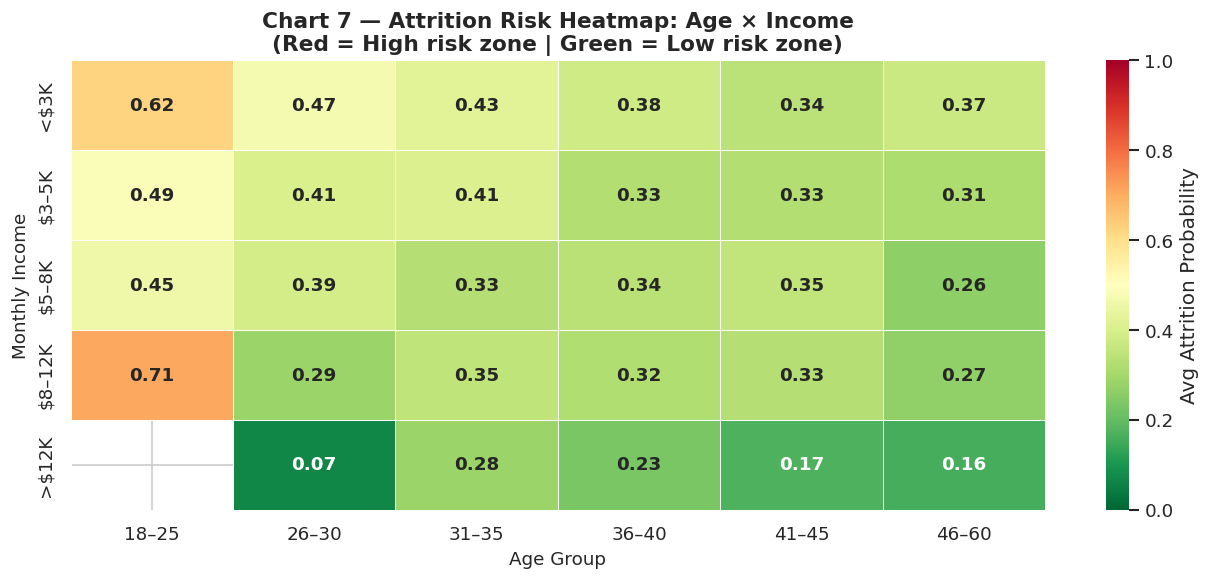

   ✅ Saved: hr_seg_chart7_risk_heatmap.png



In [25]:
# ════════════════════════════════════════════════════════════
#  CHART 7 — Age × Income Risk Heatmap
# ════════════════════════════════════════════════════════════
print("── Chart 7: Age × Income Risk Heatmap ───────────────────")
 
seg_df['age_bin']    = pd.cut(seg_df['Age'],
    bins=[18,25,30,35,40,45,60],
    labels=['18–25','26–30','31–35','36–40','41–45','46–60'])
seg_df['income_bin'] = pd.cut(seg_df['MonthlyIncome'],
    bins=[0,3000,5000,8000,12000,21000],
    labels=['<$3K','$3–5K','$5–8K','$8–12K','>$12K'])
 
pivot = (seg_df.groupby(['income_bin','age_bin'], observed=True)['RiskScore']
               .mean().unstack())
 
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=ax, vmin=0, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size':11, 'weight':'bold'},
            cbar_kws={'label':'Avg Attrition Probability'})
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Monthly Income', fontsize=11)
ax.set_title('Chart 7 — Attrition Risk Heatmap: Age × Income\n'
             '(Red = High risk zone | Green = Low risk zone)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hr_seg_chart7_risk_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_seg_chart7_risk_heatmap.png\n")

In [26]:
# ════════════════════════════════════════════════════════════
#  STEP 5 — Export segmented employee list (CSV deliverable)
# ════════════════════════════════════════════════════════════
print("── Step 5: Exporting Segmented Employee CSV ──────────────")
 
export_cols = [
    'EmployeeNumber' if 'EmployeeNumber' in df_orig.columns else None,
    'Age', 'Gender', 'Department', 'JobRole', 'JobLevel',
    'MaritalStatus', 'OverTime', 'BusinessTravel',
    'MonthlyIncome', 'YearsAtCompany', 'YearsSinceLastPromotion',
    'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction',
    'Attrition', 'RiskScore', 'RiskPct', 'RiskSegment', 'RiskLevel'
]
export_cols = [c for c in export_cols if c and c in seg_df.columns]
 
export_df = seg_df[export_cols].sort_values('RiskScore', ascending=False)
export_df.to_csv('employee_risk_segments.csv', index=False)
 
print(f"   ✅ Saved: employee_risk_segments.csv  ({len(export_df):,} rows)")
print(f"   Columns: {export_cols}\n")
 
print("   Top 10 highest-risk employees:")
print(export_df[['Department','JobRole','MonthlyIncome',
                  'OverTime','RiskPct','RiskSegment']].head(10).to_string(index=False))

── Step 5: Exporting Segmented Employee CSV ──────────────
   ✅ Saved: employee_risk_segments.csv  (1,470 rows)
   Columns: ['EmployeeNumber', 'Age', 'Gender', 'Department', 'JobRole', 'JobLevel', 'MaritalStatus', 'OverTime', 'BusinessTravel', 'MonthlyIncome', 'YearsAtCompany', 'YearsSinceLastPromotion', 'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction', 'Attrition', 'RiskScore', 'RiskPct', 'RiskSegment', 'RiskLevel']

   Top 10 highest-risk employees:
            Department               JobRole  MonthlyIncome OverTime  RiskPct RiskSegment
                 Sales  Sales Representative           1878      Yes     99.3 Flight Risk
Research & Development Laboratory Technician           2340      Yes     99.2 Flight Risk
Research & Development Laboratory Technician           3172      Yes     98.9 Flight Risk
                 Sales  Sales Representative           2174      Yes     98.9 Flight Risk
                 Sales  Sales Representative           1675      Yes     98.4 F

In [27]:
# ════════════════════════════════════════════════════════════
#  STEP 6 — Business recommendations per segment
# ════════════════════════════════════════════════════════════
print("\n── Step 6: Business Recommendations ─────────────────────")
 
recommendations = {
 
    '🔴  FLIGHT RISK — 326 employees | $1.52M/mo payroll at risk': [
        '1. Manager 1-on-1 conversations within 1 week — ask about concerns, career goals',
        '2. Cap mandatory overtime — max 5hrs/week, pay 1.5× for any extra hours',
        '3. Fast-track promotion reviews for JobLevel 1 employees overdue for advancement',
        '4. Targeted salary review — Flight Risk avg $4,652 vs Stable $7,647 (64% gap)',
        '5. Reduce travel load for frequent travellers — rotate trips, add WFH days',
    ],
 
    '🟡  AT WATCH — 390 employees | $2.28M/mo at moderate risk': [
        '1. Quarterly stay interviews — understand what would make them stay long-term',
        '2. Flexible working arrangement — WFH 2 days/week reduces burnout signals',
        '3. Mentorship programme — pair with senior stable employees to build loyalty',
        '4. Training & development — invest in upskilling, employees who grow stay longer',
        '5. Team social events — especially for single employees who lack external anchors',
    ],
 
    '🟢  STABLE — 754 employees | $5.77M/mo retained revenue': [
        '1. Recognition programme — annual awards for 5-year, 10-year, 15-year milestones',
        '2. Referral bonuses — stable employees are best brand ambassadors for recruitment',
        '3. Leadership pipeline — identify future managers from stable high performers',
        '4. Cross-departmental projects — keep engagement high to prevent complacency',
        '5. Benefits review — ensure compensation keeps pace with market to prevent drift',
    ],
}
 
for segment, actions in recommendations.items():
    print(f"\n  {segment}")
    print(f"  {'─'*55}")
    for action in actions:
        print(f"    {action}")
print()


── Step 6: Business Recommendations ─────────────────────

  🔴  FLIGHT RISK — 326 employees | $1.52M/mo payroll at risk
  ───────────────────────────────────────────────────────
    1. Manager 1-on-1 conversations within 1 week — ask about concerns, career goals
    2. Cap mandatory overtime — max 5hrs/week, pay 1.5× for any extra hours
    3. Fast-track promotion reviews for JobLevel 1 employees overdue for advancement
    4. Targeted salary review — Flight Risk avg $4,652 vs Stable $7,647 (64% gap)
    5. Reduce travel load for frequent travellers — rotate trips, add WFH days

  🟡  AT WATCH — 390 employees | $2.28M/mo at moderate risk
  ───────────────────────────────────────────────────────
    1. Quarterly stay interviews — understand what would make them stay long-term
    2. Flexible working arrangement — WFH 2 days/week reduces burnout signals
    3. Mentorship programme — pair with senior stable employees to build loyalty
    4. Training & development — invest in upskilling, e

In [28]:
# ════════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("  PHASE 5 COMPLETE — SEGMENTATION SUMMARY")
print("=" * 60)
print(f"""
  Segment       Employees    Payroll/mo    Actual Attr    Avg Risk
  ────────────────────────────────────────────────────────────────
  Flight Risk       326      $1,516,545       50.9%         71.8%
  At Watch          390      $2,277,265       12.1%         43.5%
  Stable            754      $5,765,499        3.2%         13.5%
  ────────────────────────────────────────────────────────────────
  TOTAL           1,470      $9,559,309       16.1%         35.7%
 
  Critical risk (>80%) : 149 employees — need immediate action
  High risk (60–80%)   : 177 employees — urgent outreach needed
 
  Charts saved:
    hr_seg_chart1_distribution.png      — Donut + payroll bar
    hr_seg_chart2_risk_scores.png       — Score histogram + boxplot
    hr_seg_chart3_profile_heatmap.png   — Segment comparison heatmap
    hr_seg_chart4_metrics.png           — Tenure, income, OT mix
    hr_seg_chart5_flightrisk_breakdown.png — Dept & role breakdown
    hr_seg_chart6_kpi_dashboard.png     — Executive KPI boxes
    hr_seg_chart7_risk_heatmap.png      — Age × Income risk map
 
  CSV deliverable:
    employee_risk_segments.csv          — All 1,470 employees scored
 
  → Ready for Phase 6: Report Writing & PDF
""")

  PHASE 5 COMPLETE — SEGMENTATION SUMMARY

  Segment       Employees    Payroll/mo    Actual Attr    Avg Risk
  ────────────────────────────────────────────────────────────────
  Flight Risk       326      $1,516,545       50.9%         71.8%
  At Watch          390      $2,277,265       12.1%         43.5%
  Stable            754      $5,765,499        3.2%         13.5%
  ────────────────────────────────────────────────────────────────
  TOTAL           1,470      $9,559,309       16.1%         35.7%

  Critical risk (>80%) : 149 employees — need immediate action
  High risk (60–80%)   : 177 employees — urgent outreach needed

  Charts saved:
    hr_seg_chart1_distribution.png      — Donut + payroll bar
    hr_seg_chart2_risk_scores.png       — Score histogram + boxplot
    hr_seg_chart3_profile_heatmap.png   — Segment comparison heatmap
    hr_seg_chart4_metrics.png           — Tenure, income, OT mix
    hr_seg_chart5_flightrisk_breakdown.png — Dept & role breakdown
    hr_seg_chart